#### Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
import scipy.linalg as la

### Load modelling

In [2]:
loads = {
    "New_Anuradhapura": np.array([[0.463398949696854-0.395286225877407j, 0+0j],
                                  [0+0j, 0+0j]], dtype=complex),

    "Vauniya": np.array([[0.524824254189623-0.384256700477385j, 0+0j],
                         [0+0j, 0+0j]], dtype=complex),

    "New_Habarana": np.array([[0.632725128610493-0.311862479287613j, 0+0j],
                              [0+0j, 0+0j]], dtype=complex),

    "Hambanthota": np.array([[0.88901492986599-0.125955001885902j, 0+0j],
                             [0+0j, 0+0j]], dtype=complex),

    "Pannipitiya": np.array([[0.431752314209757-0.385335143383291j, 0+0j],
                             [0+0j, 0+0j]], dtype=complex),

    "Biyagama": np.array([[-0.319239557766449-0.456981283348305j, 0+0j],
                          [0+0j, 0+0j]], dtype=complex),

    "Kelanitissa": np.array([[0.257172586954352-0.444123014167924j, 0+0j],
                          [0+0j, 0+0j]], dtype=complex),

    "Colombo_L": np.array([[0.510455626719093-0.357433647439426j, 0+0j],
                           [0+0j, 0+0j]], dtype=complex),

    "Kotugoda": np.array([[0.422191806014834-0.390207906725169j, 0+0j],
                          [0+0j, 0+0j]], dtype=complex)
}

### Line Modelling

In [3]:
line_matrices = {
    # Bus (2135+0j) → Bus (2220+0j)
    "Line 0": np.array([
        [-0.08603015-0.23795382j, 0.90881676-0.33035153j],
        [0.90881676-0.33035153j, -0.08603015-0.23795382j]
    ], dtype=complex),

    # Bus (2135+0j) → Bus (2400+0j)
    "Line 1": np.array([
        [-0.73849261+0.02750916j, -0.03078337-0.66238337j],
        [-0.03078337-0.66238337j, -0.73849261+0.02750916j]
    ], dtype=complex),

    # Bus (2135+0j) → Bus (2970+0j)
    "Line 2": np.array([
        [-0.344   -0.37162234j, 0.62979573-0.58632855j],
        [0.62979573-0.58632855j, -0.344   -0.37162234j]
    ], dtype=complex),

    # Bus (2220+0j) → Bus (2225+0j)
    "Line 3": np.array([
        [-0.03348811-0.13970532j, 0.9598002 -0.23698804j],
        [0.9598002 -0.23698804j, -0.03348811-0.13970532j]
    ], dtype=complex),

    # Bus (2220+0j) → Bus (2230+0j)
    "Line 4": np.array([
        [-0.15280413-0.30142237j, 0.83763956-0.42716069j],
        [0.83763956-0.42716069j, -0.15280413-0.30142237j]
    ], dtype=complex),

    # Bus (2220+0j) → Bus (2570+0j)
    "Line 5": np.array([
        [-0.50204874-0.34872443j, 0.44755111-0.64912133j],
        [0.44755111-0.64912133j, -0.50204874-0.34872443j]
    ], dtype=complex),

    # Bus (2220+0j) → Bus (2691+0j)
    "Line 6": np.array([
        [-0.53856942-0.17692426j, 0.24474808-0.7761149j],
        [0.24474808-0.7761149j, -0.53856942-0.17692426j]
    ], dtype=complex),

    # Bus (2222+0j) → Bus (2300+0j)
    "Line 7": np.array([
        [-0.05919349-0.23212512j, 0.94070804-0.24002894j],
        [0.94070804-0.24002894j, -0.05919349-0.23212512j]
    ], dtype=complex),

    # Bus (2230+0j) → Bus (2240+0j)
    "Line 8": np.array([
        [-0.00798967-0.04741527j, 0.98096153-0.1834746j],
        [0.98096153-0.1834746j, -0.00798967-0.04741527j]
    ], dtype=complex),

    # Bus (2240+0j) → Bus (2250+0j)
    "Line 9": np.array([
        [-1.60356654e-04-0.0091862j, 9.99184114e-01-0.03498877j],
        [9.99184114e-01-0.03498877j, -1.60356654e-04-0.0091862j]
    ], dtype=complex),

    # Bus (2245+0j) → Bus (2280+0j)
    "Line 10": np.array([
        [-0.33454578-0.29860731j, 0.58624699-0.66822921j],
        [0.58624699-0.66822921j, -0.33454578-0.29860731j]
    ], dtype=complex),

    # Bus (2245+0j) → Bus (2705+0j)
    "Line 11": np.array([
        [-0.3793227 -0.37253837j, 0.59024368-0.60456732j],
        [0.59024368-0.60456732j, -0.3793227 -0.37253837j]
    ], dtype=complex),

    # Bus (2280+0j) → Bus (2281+0j)
    "Line 12": np.array([
        [-0.15186381-0.30074541j, 0.83863247-0.42601589j],
        [0.83863247-0.42601589j, -0.15186381-0.30074541j]
    ], dtype=complex),

    # Bus (2300+0j) → Bus (2570+0j)
    "Line 13": np.array([
        [-0.02779126-0.1422927j, 0.97003954-0.19259659j],
        [0.97003954-0.19259659j, -0.02779126-0.1422927j]
    ], dtype=complex),

    # Bus (2305+0j) → Bus (2306+0j)
    "Line 14": np.array([
        [-0.01491776-0.1205505j, 0.98506985-0.12194652j],
        [0.98506985-0.12194652j, -0.01491776-0.1205505j]
    ], dtype=complex),

    # Bus (2305+0j) → Bus (2350+0j)
    "Line 15": np.array([
        [-0.74045907-0.39884195j, 0.2559327 -0.47575838j],
        [0.2559327 -0.47575838j, -0.74045907-0.39884195j]
    ], dtype=complex),

    # Bus (2306+0j) → Bus (2580+0j)
    "Line 16": np.array([
        [-0.06009976-0.20362754j, 0.93612334-0.27859975j],
        [0.93612334-0.27859975j, -0.06009976-0.20362754j]
    ], dtype=complex),

    # Bus (2307+0j) → Bus (2580+0j)
    "Line 17": np.array([
        [-0.0601255 -0.2036573j, 0.93610167-0.27865635j],
        [0.93610167-0.27865635j, -0.0601255 -0.2036573j]
    ], dtype=complex),

    # Bus (2560+0j) → Bus (2570+0j)
    "Line 18": np.array([
        [0.00122521-0.00018215j, 0.99107891-0.12361668j],
        [0.99107891-0.12361668j, 0.00122521-0.00018215j]
    ], dtype=complex),

    # Bus (2561+0j) → Bus (2570+0j)
    "Line 19": np.array([
        [0.00122521-0.00018215j, 0.99107891-0.12361668j],
        [0.99107891-0.12361668j, 0.00122521-0.00018215j]
    ], dtype=complex),

    # Bus (2561+0j) → Bus (2970+0j)
    "Line 20": np.array([
        [-0.06787297-0.21511363j, 0.92789541-0.29509593j],
        [0.92789541-0.29509593j, -0.06787297-0.21511363j]
    ], dtype=complex),

    # Bus (2570+0j) → Bus (2580+0j)
    "Line 21": np.array([
        [-0.03749376-0.14718617j, 0.95509345-0.25024799j],
        [0.95509345-0.25024799j, -0.03749376-0.14718617j]
    ], dtype=complex),

    # Bus (2580+0j) → Bus (2830+0j)
    "Line 22": np.array([
        [-0.05391906-0.19378478j, 0.94266337-0.26458195j],
        [0.94266337-0.26458195j, -0.05391906-0.19378478j]
    ], dtype=complex),

    # Bus (2691+0j) → Bus (2705+0j)
    "Line 23": np.array([
        [0.00430959-0.0025505j, 0.8598635 -0.50016576j],
        [0.8598635 -0.50016576j, 0.00430959-0.0025505j]
    ], dtype=complex),

    # Bus (2705+0j) → Bus (2810+0j)
    "Line 24": np.array([
        [-0.63665484-0.24351772j, 0.255518 -0.67943316j],
        [0.255518 -0.67943316j, -0.63665484-0.24351772j]
    ], dtype=complex),

    # Bus (2810+0j) → Bus (2815+0j)
    "Line 25": np.array([
        [-0.52722368-0.34556313j, 0.42252474-0.64839422j],
        [0.42252474-0.64839422j, -0.52722368-0.34556313j]
    ], dtype=complex),

    # Bus (2815+0j) → Bus (2830+0j)
    "Line 26": np.array([
        [-0.24958058-0.34757734j, 0.73118903-0.52855055j],
        [0.73118903-0.52855055j, -0.24958058-0.34757734j]
    ], dtype=complex)
}

### Source Modelling

In [4]:
Gamma_S = 1+0j
source_matrices = np.array([
    [0.0 + 0j, 0.0 + 0j],
    [1.0 + 0j, Gamma_S]
], dtype=complex)

### Junction Modelling

In [5]:
def ideal_junction(n):
    S = np.full((n, n), 2.0/n, dtype=complex)
    np.fill_diagonal(S, -(n-2)/n)
    return S

Junctions = {
    "NPOLP_2": ideal_junction(3),
    "KOTMA-2": ideal_junction(5),
    "HAMBAN-2": ideal_junction(2),
    "PADUKKA_2": ideal_junction(2),
    "UPPER-KOTH": np.array([
        [1.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j]
    ]),                      
    "VICTO-2": ideal_junction(2),
    "BIYAG-2": ideal_junction(6),
    "NHAB-2": ideal_junction(3),
    "BARGE-2": ideal_junction(2),
    "KELAN-2": ideal_junction(3),
    "RANDE-2": ideal_junction(2),
    "RANTE-2": ideal_junction(2),
    "VAVUNIYA-2": ideal_junction(3),
    "MANNAR-2": ideal_junction(2),
    "NEWANU-2": ideal_junction(4),
    "NADUKUDA-2": np.array([
        [1.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j]
    ]),
    "KERAWALA_2": ideal_junction(2),
    "NEW_KERA2": ideal_junction(2),
    "COL_L2": ideal_junction(2),
    "KOTUG-2": ideal_junction(5),
    "NEW_KERA": np.array([
        [1.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j]
    ]),
    "PANNI-2": ideal_junction(2),
    "PANNI-D-2": ideal_junction(2),
    "VEYAN-2": ideal_junction(2),
    "PUTTALAM-PS": ideal_junction(3),
    "NCHILAW-2": ideal_junction(2)
}



### Tranformer Modelling

In [6]:
import numpy as np

Transformers = {
    "New_Anuradhapura": np.array([
        [-2.75189702390157-0.159077016865155j,  3.75189702390157+0.159077016865155j],
        [ 3.75189702390157+0.159077016865155j, -2.75189702390157-0.159077016865155j]
    ]),

    "Vauniya": np.array([
        [-0.682700251143479-0.19280417680884j,  1.68270025114348+0.19280417680884j],
        [ 1.68270025114348+0.19280417680884j,  -0.682700251143479-0.19280417680884j]
    ]),

    "New_Habarana": np.array([
        [-0.944126705512449-0.0371194369615269j,  1.94412670551245+0.0371194369615269j],
        [ 1.94412670551245+0.0371194369615269j,  -0.944126705512449-0.0371194369615269j]
    ]),

    "Hambanthota": np.array([
        [ 1.01209194050863-0.00833617029118667j, -0.0120919405086299+0.00833617029118667j],
        [-0.0120919405086299+0.00833617029118667j, 1.01209194050863-0.00833617029118667j]
    ]),

    "Pannipitiya": np.array([
        [ 0.136275243824987-0.508465147472719j,  0.863724756175013+0.508465147472719j],
        [ 0.863724756175013+0.508465147472719j,  0.136275243824987-0.508465147472719j]
    ]),

    "Biyagama": np.array([
        [ 0.539688061981591-0.561058293901193j,  0.460311938018409+0.561058293901193j],
        [ 0.460311938018409+0.561058293901193j,  0.539688061981591-0.561058293901193j]
    ]),

    "Kelanitissa": np.array([
        [ 2.27518638161526-0.30039788068165j,   -1.27518638161526+0.30039788068165j],
        [-1.27518638161526+0.30039788068165j,    2.27518638161526-0.30039788068165j]
    ]),

    "Colombo_L": np.array([
        [ 2.62552755091198-0.20043454951018j,   -1.62552755091198+0.20043454951018j],
        [-1.62552755091198+0.20043454951018j,    2.62552755091198-0.20043454951018j]
    ]),

    "Kotugoda": np.array([
        [-1.69881647926494-0.649055537465153j,   2.69881647926494+0.649055537465153j],
        [ 2.69881647926494+0.649055537465153j,  -1.69881647926494-0.649055537465153j]
    ])
}

### S Matrix

In [7]:
S_matrix = [
    # --- Source 1 & Puttalam ---
    source_matrices,              # Source-1 (2)
    Junctions['PUTTALAM-PS'],                 # Puttalam (3 connections)
    line_matrices["Line 24"],     # Line 24: N.Anu -> Puttalam (2)

    # --- Northern Hubs ---
    Junctions['NEWANU-2'],                 # N.Anu (4 connections)
    Transformers["New_Anuradhapura"], 
    loads["New_Anuradhapura"],        
    line_matrices["Line 11"],     # Line 11: Vavuniya -> N.Anu
    
    Junctions['VAVUNIYA-2'],                 # Vavuniya (3 connections)
    Transformers["Vauniya"],          
    loads["Vauniya"],                 
    line_matrices["Line 10"],     # Line 10: Vavuniya -> Mannar

    Junctions['MANNAR-2'],                 # Mannar (2 connections)
    line_matrices["Line 12"],     # Line 12: Mannar -> Nadukuda
    Junctions['NADUKUDA-2'],                 # Nadukuda dead-end cap (2)

    # --- Western Coast ---
    line_matrices["Line 25"],     # Line 25: Puttalam -> N.Chilaw
    Junctions['NCHILAW-2'],                 # N.Chilaw (2 connections)
    line_matrices["Line 26"],     # Line 26: N.Chilaw -> Veyangoda
    Junctions['VEYAN-2'],                 # Veyangoda (2 connections)

    # --- Kotugoda Hub ---
    line_matrices["Line 22"],     # Line 22: Kotugoda -> Veyangoda
    Junctions['KOTUG-2'],                 # Kotugoda (5 connections)
    Transformers["Kotugoda"],         
    loads["Kotugoda"],                

    # --- Kerawalapitiya Area ---
    line_matrices["Line 17"],     # Line 17: N.Kera -> Kotugoda
    Junctions['NEW_KERA'],                 # N.Kera dead-end cap (2)

    line_matrices["Line 16"],     # Line 16: N.Kera 2 -> Kotugoda
    Junctions['NEW_KERA2'],                 # N.Kera 2 (2 connections)

    line_matrices["Line 14"],     # Line 14: Kera 2 -> N.Kera 2
    Junctions['KERAWALA_2'],                 # Kera 2 (2 connections)

    line_matrices["Line 15"],     # Line 15: Kera 2 -> Col-L
    Junctions['COL_L2'],                 # Col-L (2 connections)
    Transformers["Colombo_L"],        
    loads["Colombo_L"],               

    # --- Biyagama Hub ---
    line_matrices["Line 21"],     # Line 21: Biyagama -> Kotugoda
    Junctions['BIYAG-2'],                 # Biyagama (6 connections)
    Transformers["Biyagama"],         
    loads["Biyagama"],                

    # --- Kelaniya & Barge ---
    line_matrices["Line 13"],     # Line 13: Kelaniya -> Biyagama
    Junctions['KELAN-2'],                 # Kelaniya (3 connections)
    Transformers["Kelanitissa"],         
    loads["Kelanitissa"],                
    
    line_matrices["Line 7"],      # Line 7: Barge -> Kelaniya
    Junctions['BARGE-2'],                 # Barge (2 connections)
    source_matrices,              # Source-3 (Barge)

    # --- Pannipitiya & Padukka ---
    line_matrices["Line 18"],     # Line 18: Panni -> Biyagama
    Junctions['PANNI-2'],                 # Pannipitiya (2 connections)
    Transformers["Pannipitiya"],      
    loads["Pannipitiya"],             

    line_matrices["Line 19"],     # Line 19: Panni D2 -> Biyagama
    Junctions['PANNI-D-2'],                 # Panni D2 (2 connections)

    line_matrices["Line 20"],     # Line 20: Panni D2 -> Padukka
    Junctions['PADUKKA_2'],                 # Padukka (2 connections)

    # --- Southern & Highlands ---
    line_matrices["Line 2"],      # Line 2: N.Polpitiya -> Padukka
    Junctions['NPOLP_2'],                 # N.Polpitiya (3 connections)

    line_matrices["Line 1"],      # Line 1: N.Polpitiya -> Hambantota
    Junctions['HAMBAN-2'],                 # Hambantota (2 connections)
    Transformers["Hambanthota"],      
    loads["Hambanthota"],             

    line_matrices["Line 0"],      # Line 0: N.Polpitiya -> Kotmale
    Junctions['KOTMA-2'],                 # Kotmale (5 connections)

    line_matrices["Line 3"],      # Line 3: Kotmale -> U.Kotmale
    Junctions['UPPER-KOTH'],                 # U.Kotmale dead-end cap (2)

    line_matrices["Line 4"],      # Line 4: Kotmale -> Victoria
    Junctions['VICTO-2'],                 # Victoria (2 connections)

    line_matrices["Line 8"],      # Line 8: Victoria -> Randenigala
    Junctions['RANDE-2'],                 # Randenigala (2 connections)

    line_matrices["Line 9"],      # Line 9: Randenigala -> Rantambe
    Junctions['RANTE-2'],                 # Rantambe (2 connections)
    source_matrices,              # Source-2 (Rantambe)

    # --- Ties back to Hubs ---
    line_matrices["Line 5"],      # Line 5: Kotmale -> Biyagama
    
    line_matrices["Line 6"],      # Line 6: Kotmale -> N.Habarana
    Junctions['NHAB-2'],                 # N.Habarana (3 connections)
    Transformers["New_Habarana"],     
    loads["New_Habarana"],            
    
    line_matrices["Line 23"]      # Line 23: N.Habarana -> N.Anu
]

# Matrix size
total_size = sum(m.shape[0] for m in S_matrix)
print(f"Total S_matrix size: {total_size} × {total_size}")

# Assemble the final Diagonal Matrix
S_global = block_diag(*S_matrix)
print(f"Final S_matrix shape: {S_global.shape}")

print(S_global)

Total S_matrix size: 165 × 165
Final S_matrix shape: (165, 165)
[[ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 1.        +0.j          1.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         -0.33333333+0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 ...
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.00430959-0.0025505j
   0.8598635 -0.50016576j]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  ...  0.        +0.j          0.8598635 -0.50016576j
   0.00430959-0.0025505j ]]


### C-Matrix

In [8]:
C_matrix_perfect = np.zeros((165, 165), dtype=complex)

connections = [
    # --- Source 1 & Puttalam Area ---
    (1, 4),      # Source-1 to Puttalam Junction 'Source_Gen'
    (2, 5),      # Puttalam Junction to Line 24
    (3, 32),     # Puttalam Junction to Line 25
    
    # --- Northern Hubs (New Anuradhapura, Vavuniya, Mannar) ---
    (6, 9),      # Line 24 to New Anuradhapura Junction
    (7, 15),     # New Anuradhapura to Line 11
    (8, 164),    # New Anuradhapura to Line 23
    (10, 11),    # New Anuradhapura to Transformer
    (12, 13),    # Transformer to Load
    (16, 18),    # Line 11 to Vavuniya Junction
    (17, 24),    # Vavuniya to Line 10
    (19, 20),    # Vavuniya to Transformer
    (21, 22),    # Transformer to Load
    (25, 26),    # Line 10 to Mannar Junction
    (27, 28),    # Mannar to Line 12
    (29, 30),    # Line 12 to Nadukuda Junction
                 # Port 31 (Nadukuda Dummy_Open) is intentionally left unconnected
                 
    # --- Western Coast (Chilaw to Veyangoda) ---
    (33, 34),    # Line 25 to New Chilaw Junction
    (35, 36),    # New Chilaw to Line 26
    (37, 39),    # Line 26 to Veyangoda Junction
    (38, 40),    # Veyangoda to Line 22
    
    # --- Kotugoda Hub ---
    (41, 45),    # Line 22 to Kotugoda Junction
    (42, 56),    # Kotugoda to Line 16
    (43, 52),    # Kotugoda to Line 17
    (44, 72),    # Kotugoda to Line 21
    (46, 47),    # Kotugoda to Transformer
    (48, 49),    # Transformer to Load
    
    # --- Kerawalapitiya Area ---
    (51, 53),    # Line 17 to New Kerawalapitiya Junction
                 # Port 54 (New Kera Dummy_Open) is unconnected
    (55, 58),    # Line 16 to New Kerawalapitiya 2 Junction
    (57, 60),    # New Kerawalapitiya 2 to Line 14
    (59, 61),    # Line 14 to Kerawalapitiya Junction
    (62, 63),    # Kerawalapitiya to Line 15
    (64, 65),    # Line 15 to Colombo-L Junction
    (66, 67),    # Colombo-L to Transformer
    (68, 69),    # Transformer to Load
    
    # --- Central Hub (Biyagama, Kelaniya, Barge) ---
    (71, 77),    # Line 21 to Biyagama Junction
    (73, 153),   # Biyagama to Line 5 (UGC)
    (74, 84),    # Biyagama to Line 13
    (75, 99),    # Biyagama to Line 18
    (76, 107),   # Biyagama to Line 19
    (78, 79),    # Biyagama to Transformer
    (80, 81),    # Transformer to Load
    (83, 86),    # Line 13 to Kelaniya Junction
    (85, 93),    # Kelaniya to Line 7
    (87, 88),    # Kelaniya to Transformer
    (89, 90),    # Transformer to Load
    (92, 94),    # Line 7 to Barge Junction
    (95, 97),    # Barge Junction to Source-3 (Barge)
    
    # --- South Western Region (Pannipitiya & Padukka) ---
    (98, 100),   # Line 18 to Pannipitiya Junction
    (101, 102),  # Pannipitiya to Transformer
    (103, 104),  # Transformer to Load
    (106, 108),  # Line 19 to Panni D2 Junction
    (109, 110),  # Panni D2 to Line 20
    (111, 113),  # Line 20 to Padukka Junction
    (112, 115),  # Padukka to Line 2
    
    # --- Southern Region (New Polpitiya & Hambantota) ---
    (114, 118),  # Line 2 to New Polpitiya Junction
    (116, 127),  # New Polpitiya to Line 0
    (117, 119),  # New Polpitiya to Line 1
    (120, 121),  # Line 1 to Hambantota Junction
    (122, 123),  # Hambantota to Transformer
    (124, 125),  # Transformer to Load
    
    # --- Highlands (Kotmale, Victoria, Rantambe) ---
    (128, 129),  # Line 0 to Kotmale Junction
    (130, 134),  # Kotmale to Line 3
    (131, 138),  # Kotmale to Line 4
    (132, 152),  # Kotmale to Line 5 (UGC)
    (133, 154),  # Kotmale to Line 6
    (135, 136),  # Line 3 to Upper Kotmale Junction
                 # Port 137 (U.Koth Dummy_Open) is unconnected
    (139, 140),  # Line 4 to Victoria Junction
    (141, 142),  # Victoria to Line 8
    (143, 144),  # Line 8 to Randenigala Junction
    (145, 146),  # Randenigala to Line 9
    (147, 148),  # Line 9 to Rantambe Junction
    (149, 151),  # Rantambe Junction to Source-2 (Rantambe)
    
    # --- Eastern/North-Central Corridor (Habarana) ---
    (155, 156),  # Line 6 to New Habarana Junction
    (157, 163),  # New Habarana to Line 23
    (158, 159),  # New Habarana to Transformer
    (160, 161)   # Transformer to Load
]

for p1, p2 in connections:
    C_matrix_perfect[p1, p2] = 1.0
    C_matrix_perfect[p2, p1] = 1.0


### Solving Network Matrix

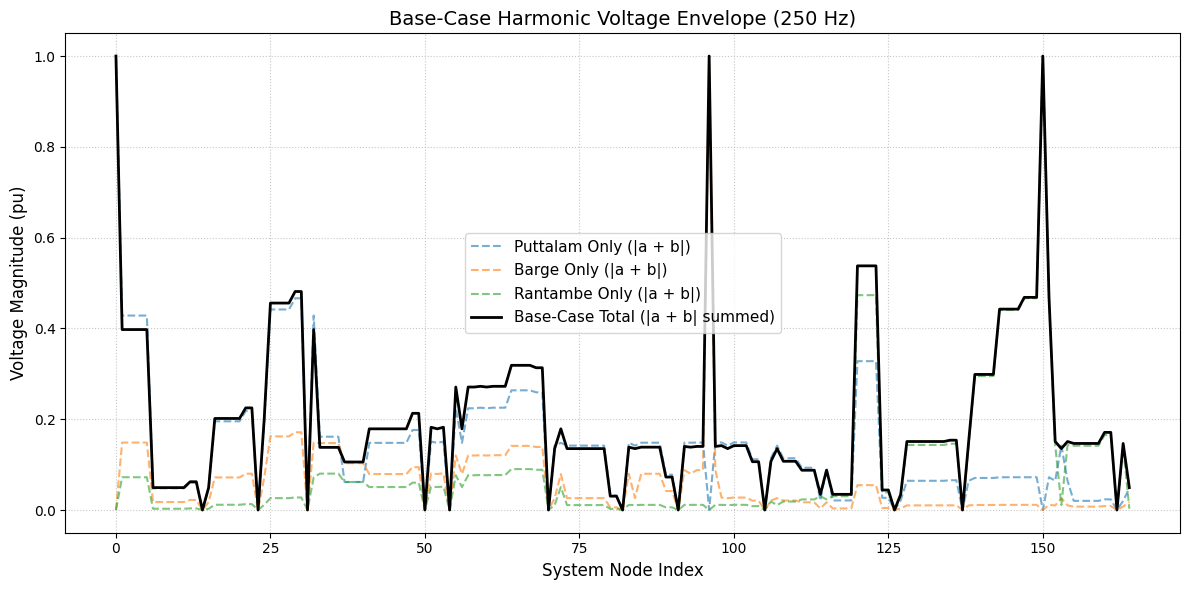

In [9]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# 1. Define specific phase angles (in degrees) and magnitudes
source_injections = {
    "Puttalam_Source": {"mag": 1.0, "angle_deg": 30.0},   # Example: 30 degrees
    "Barge_Source": {"mag": 1.0, "angle_deg": -45.0},     # Example: -45 degrees
    "Rantambe_Source": {"mag": 1.0, "angle_deg": 120.0}   # Example: 120 degrees
}

N = 165

I_matrix = np.eye(N, dtype=complex)
# Network Matrix M for the equation M @ a = 0 (homogeneous system)
# Assumes C_matrix_perfect and S_global are already defined
M = I_matrix - (C_matrix_perfect @ S_global) 

# Define source indices for the three sources in the system
source_indices = {
    "Puttalam_Source": 0,
    "Barge_Source": 96,
    "Rantambe_Source": 150
}

A_individual = {}
B_individual = {}
V_individual_complex = {}
V_individual_mag = {}

for src_name, k in source_indices.items():
    
    a_vec = np.zeros((N, 1), dtype=complex)
    
    # 2. Extract magnitude and convert degrees to radians
    mag = source_injections[src_name]["mag"]
    angle_rad = np.radians(source_injections[src_name]["angle_deg"])
    
    # 3. Apply Euler's formula to create the complex injection phasor
    a_vec[k, 0] = mag * np.exp(1j * angle_rad) 
    
    mask = np.arange(N) != k
    
    M_sub = M[np.ix_(mask, mask)]  
    M_col = M[mask, k].reshape(-1, 1)             
    
    # Solve for unknown incident waves
    rhs = -M_col * a_vec[k, 0]
    a_sub = la.solve(M_sub, rhs)
    
    # Reassemble 'a' and calculate 'b'
    a_vec[mask, 0] = a_sub.flatten()
    b_vec = S_global @ a_vec  
    
    V_individual_complex[src_name] = a_vec + b_vec
    A_individual[src_name] = a_vec.flatten()
    B_individual[src_name] = b_vec.flatten()
    V_individual_mag[src_name] = np.abs(V_individual_complex[src_name])

V_total_complex = sum(V_individual_complex.values())
V_total_mag = np.abs(V_total_complex)
a_total = sum(A_individual.values())
b_total = sum(B_individual.values())

nodes = np.arange(N)

plt.figure(figsize=(12, 6))
plt.plot(nodes, V_individual_mag["Puttalam_Source"], label='Puttalam Only (|a + b|)', alpha=0.6, linestyle='--')
plt.plot(nodes, V_individual_mag["Barge_Source"], label='Barge Only (|a + b|)', alpha=0.6, linestyle='--')
plt.plot(nodes, V_individual_mag["Rantambe_Source"], label='Rantambe Only (|a + b|)', alpha=0.6, linestyle='--')
plt.plot(nodes, V_total_mag, label='Base-Case Total (|a + b| summed)', color='black', linewidth=2)
plt.title('Base-Case Harmonic Voltage Envelope (250 Hz)', fontsize=14)
plt.xlabel('System Node Index', fontsize=12)
plt.ylabel('Voltage Magnitude (pu)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()  
plt.show()

### Individual Source Propagation Throughout the Network

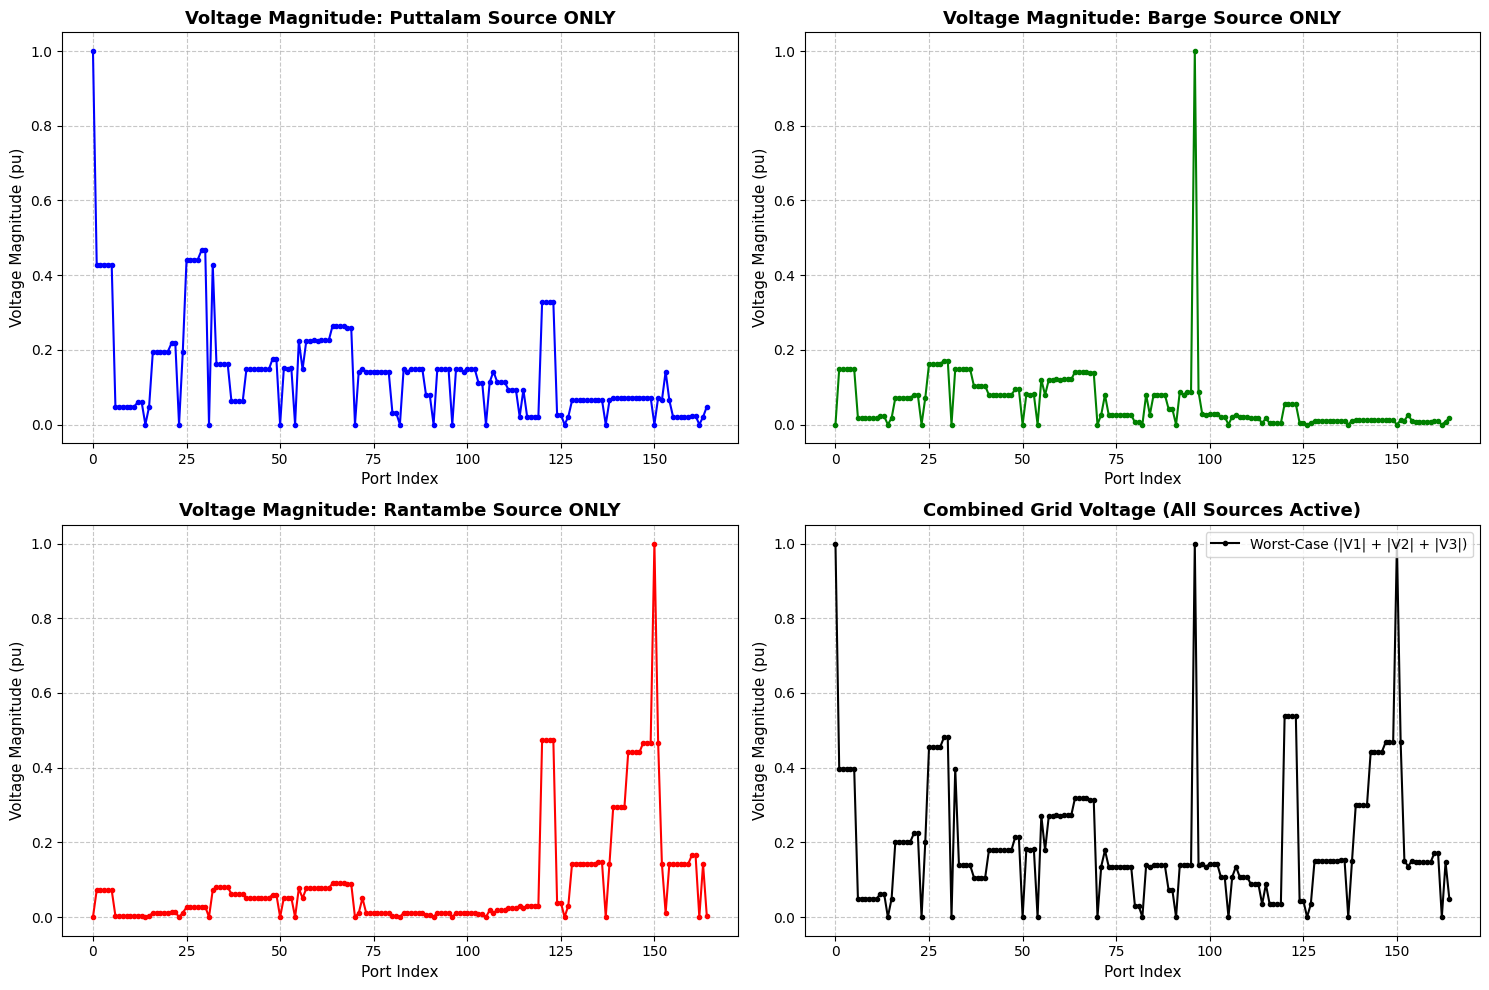

In [10]:

ports = np.arange(N)

plt.figure(figsize=(15, 10))

# --- Subplot 1: Puttalam Source ---
plt.subplot(2, 2, 1)
plt.title("Voltage Magnitude: Puttalam Source ONLY", fontsize=13, fontweight='bold')
plt.plot(ports, np.abs(V_individual_mag["Puttalam_Source"]), marker='.', linestyle='-', color='blue')
plt.ylabel("Voltage Magnitude (pu)", fontsize=11)
plt.xlabel("Port Index", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# --- Subplot 2: Barge Source ---
plt.subplot(2, 2, 2)
plt.title("Voltage Magnitude: Barge Source ONLY", fontsize=13, fontweight='bold')
plt.plot(ports, np.abs(V_individual_mag["Barge_Source"]), marker='.', linestyle='-', color='green')
plt.ylabel("Voltage Magnitude (pu)", fontsize=11)
plt.xlabel("Port Index", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# --- Subplot 3: Rantambe Source ---
plt.subplot(2, 2, 3)
plt.title("Voltage Magnitude: Rantambe Source ONLY", fontsize=13, fontweight='bold')
plt.plot(ports, np.abs(V_individual_mag["Rantambe_Source"]), marker='.', linestyle='-', color='red')
plt.ylabel("Voltage Magnitude (pu)", fontsize=11)
plt.xlabel("Port Index", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# --- Subplot 4: Superimposed Total ---
plt.subplot(2, 2, 4)
plt.title("Combined Grid Voltage (All Sources Active)", fontsize=13, fontweight='bold')
plt.plot(ports, V_total_mag, marker='.', linestyle='-', color='black', linewidth=1.5, label="Worst-Case (|V1| + |V2| + |V3|)")
plt.ylabel("Voltage Magnitude (pu)", fontsize=11)
plt.xlabel("Port Index", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Case Study

In [11]:
network = {
    "Puttalam Junction": [2, 3, 4],
    "New Anuradhapura Junction": [7, 8, 9, 10],
    "Vavuniya Junction": [17, 18, 19],
    "Mannar Junction": [26, 27],
    "Nadukuda Junction": [30, 31],
    "New Chilaw Junction": [34, 35],
    "Veyangoda Junction": [38, 39],
    "Kotugoda Junction": [42, 43, 44, 45, 46],
    "New Kerawalapitiya Junction": [53, 54],
    "New Kerawalapitiya 2 Junction": [57, 58],
    "Kerawalapitiya Junction": [61, 62],
    "Colombo-L Junction": [65, 66],
    "Biyagama Junction": [73, 74, 75, 76, 77, 78],
    "Kelaniya Junction": [85, 86, 87],
    "Barge Junction": [94, 95],
    "Pannipitiya Junction": [100, 101],
    "Panni D2 Junction": [108, 109],
    "Padukka Junction": [112, 113],
    "New Polpitiya Junction": [116, 117, 118],
    "Hambantota Junction": [121, 122],
    "Kotmale Junction": [129, 130, 131, 132, 133],
    "Upper Kotmale Junction": [136, 137],
    "Victoria Junction": [140, 141],
    "Randenigala Junction": [144, 145],
    "Rantambe Junction": [148, 149],
    "New Habarana Junction": [156, 157, 158],

}

In [12]:
print("\n=== CORRECTED JUNCTION VOLTAGES ===")
for junction, ports in network.items(): # Use your dictionary name
    # Take the voltage of the FIRST port only. Do not sum them!
    actual_voltage = V_total_mag[ports[0]][0] 
    print(f"{junction:30}: Voltage Magnitude = {actual_voltage:.4f} pu")


=== CORRECTED JUNCTION VOLTAGES ===
Puttalam Junction             : Voltage Magnitude = 0.3975 pu
New Anuradhapura Junction     : Voltage Magnitude = 0.0494 pu
Vavuniya Junction             : Voltage Magnitude = 0.2017 pu
Mannar Junction               : Voltage Magnitude = 0.4559 pu
Nadukuda Junction             : Voltage Magnitude = 0.4813 pu
New Chilaw Junction           : Voltage Magnitude = 0.1380 pu
Veyangoda Junction            : Voltage Magnitude = 0.1058 pu
Kotugoda Junction             : Voltage Magnitude = 0.1788 pu
New Kerawalapitiya Junction   : Voltage Magnitude = 0.1823 pu
New Kerawalapitiya 2 Junction : Voltage Magnitude = 0.2709 pu
Kerawalapitiya Junction       : Voltage Magnitude = 0.2725 pu
Colombo-L Junction            : Voltage Magnitude = 0.3187 pu
Biyagama Junction             : Voltage Magnitude = 0.1352 pu
Kelaniya Junction             : Voltage Magnitude = 0.1385 pu
Barge Junction                : Voltage Magnitude = 0.1401 pu
Pannipitiya Junction          : V

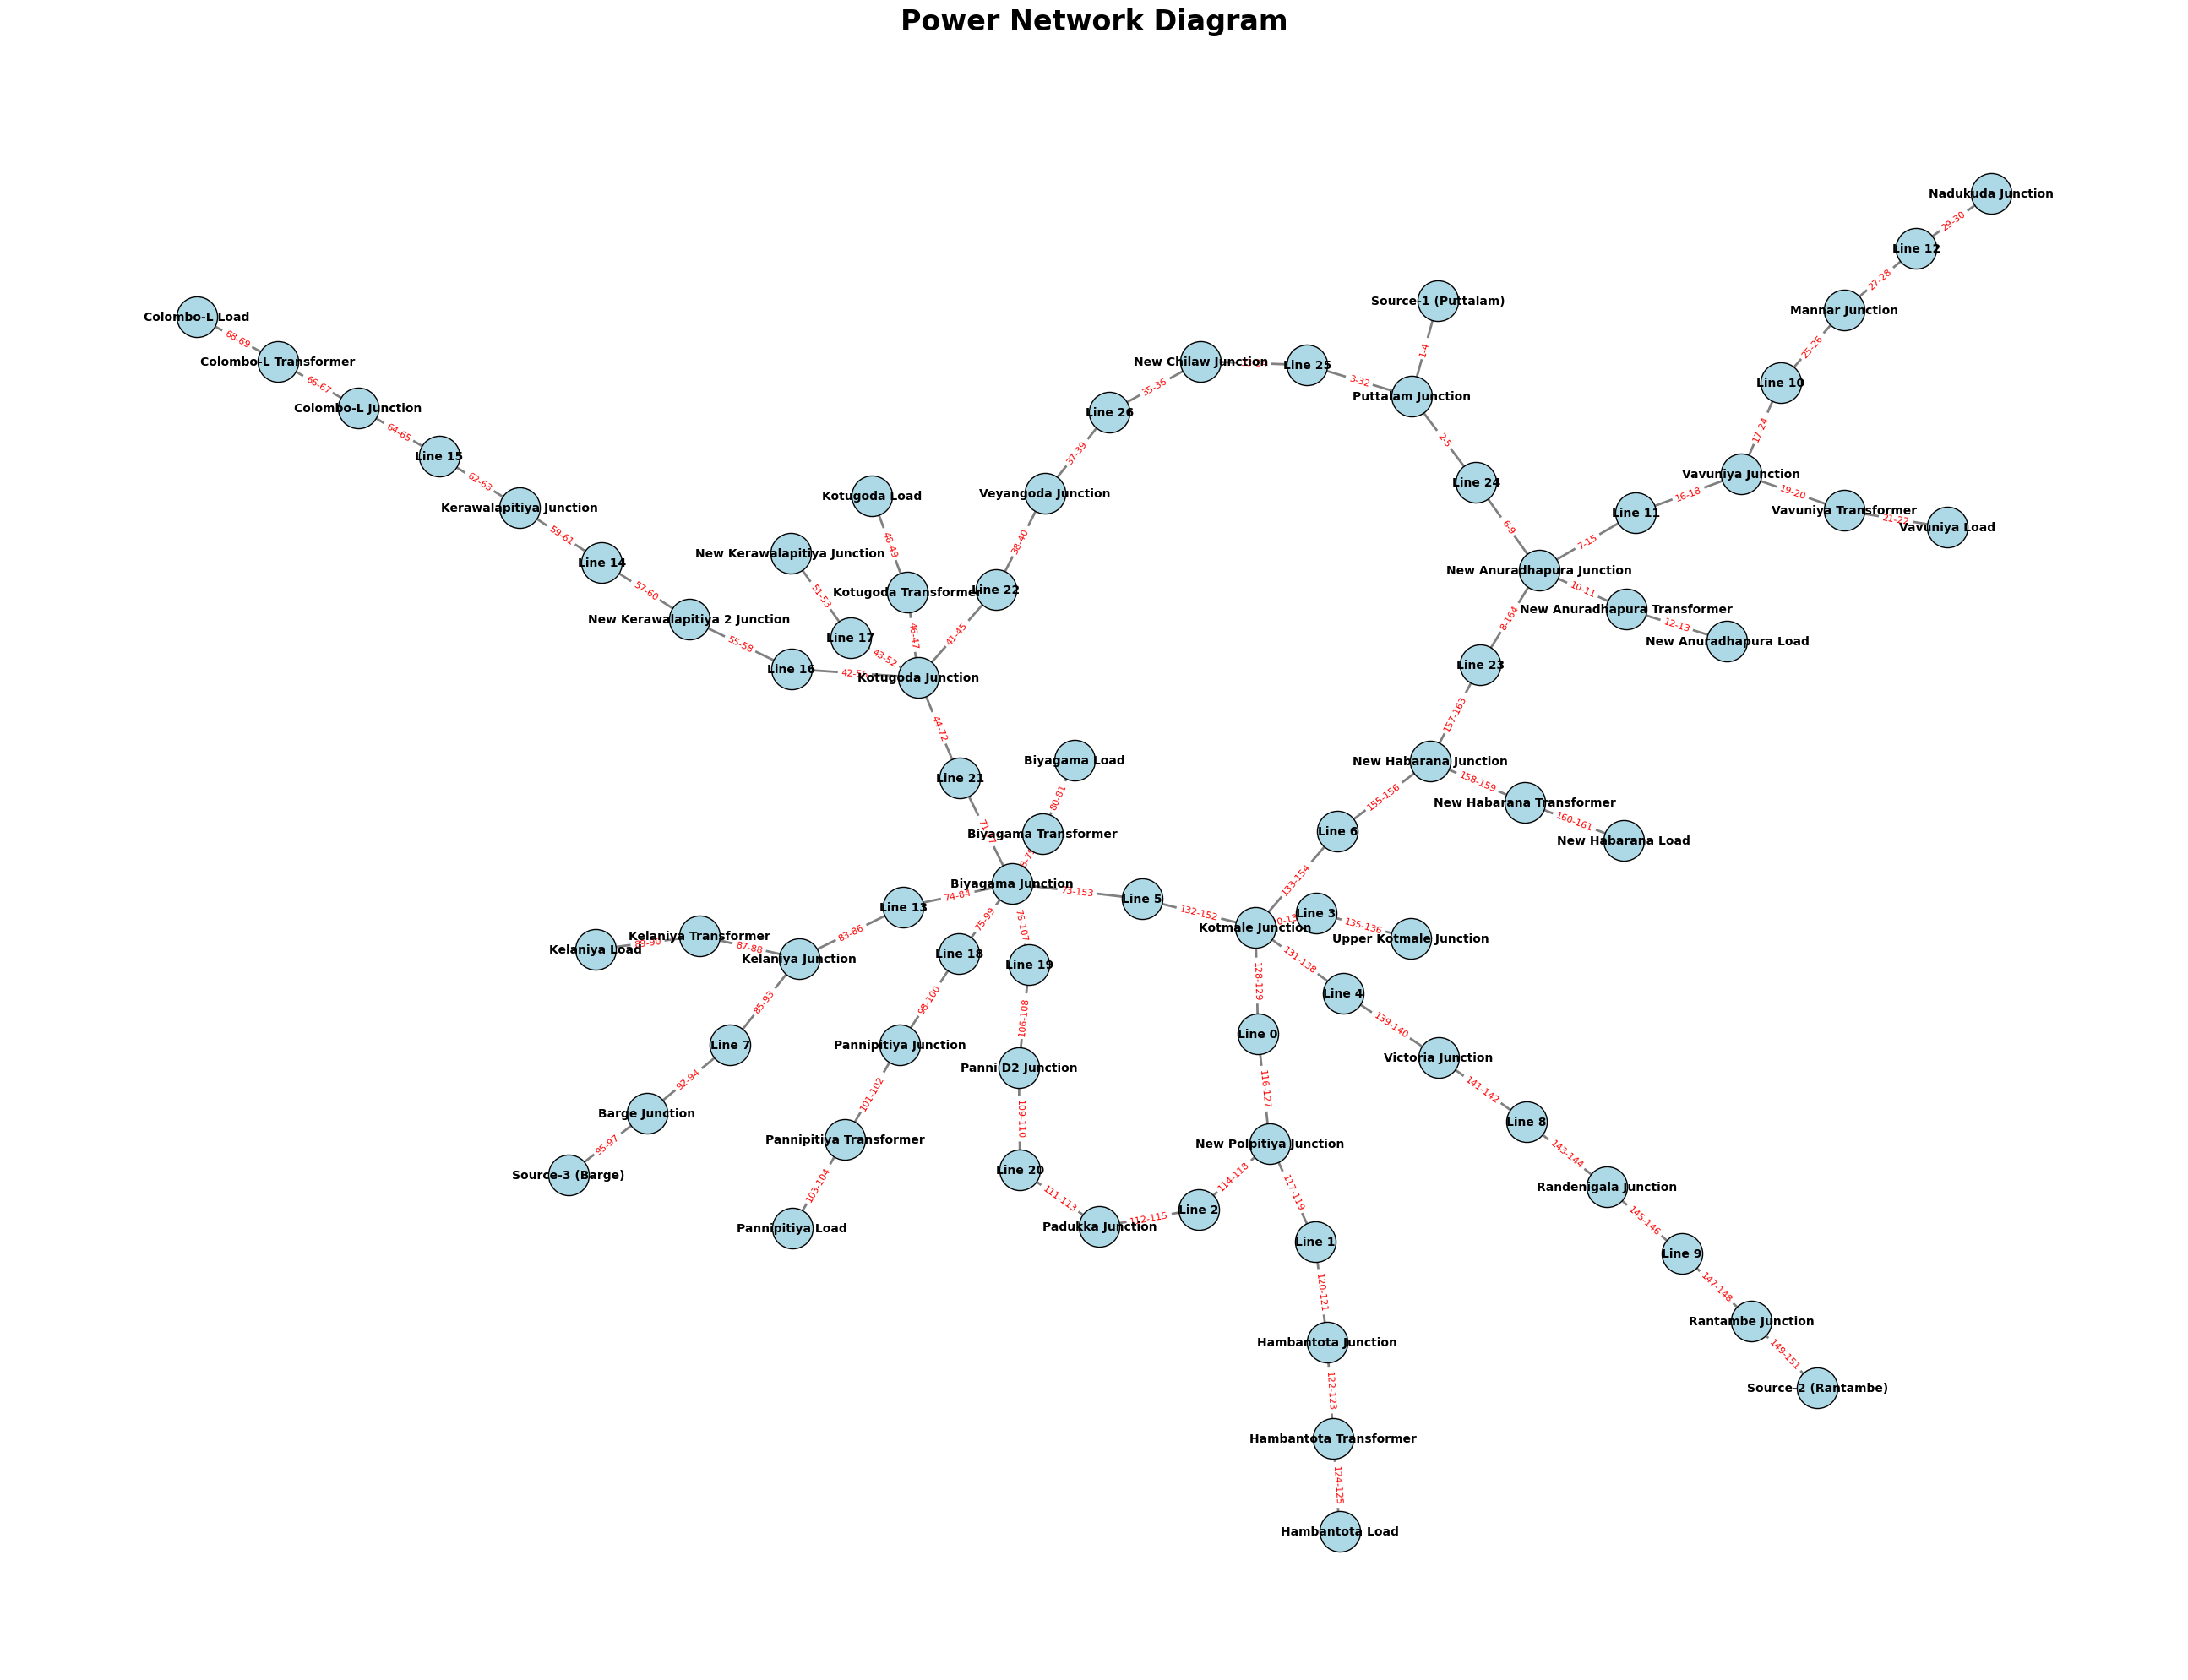

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE MAPPINGS AND CONNECTIONS
# ==========================================
network_port_mapping = {
    # --- NORTH / WEST REGION ---
    "Source-1 (Puttalam)": [0, 1],
    "Puttalam Junction": [2, 3, 4],
    "Line 24": [5, 6],
    "New Anuradhapura Junction": [7, 8, 9, 10],
    "New Anuradhapura Transformer": [11, 12],
    "New Anuradhapura Load": [13, 14],
    "Line 11": [15, 16],
    "Vavuniya Junction": [17, 18, 19],
    "Vavuniya Transformer": [20, 21],
    "Vavuniya Load": [22, 23],
    "Line 10": [24, 25],
    "Mannar Junction": [26, 27],
    "Line 12": [28, 29],
    "Nadukuda Junction": [30, 31],
    "Line 25": [32, 33],
    "New Chilaw Junction": [34, 35],
    "Line 26": [36, 37],
    "Veyangoda Junction": [38, 39],

    # --- WESTERN COAST / COLOMBO REGION ---
    "Line 22": [40, 41],
    "Kotugoda Junction": [42, 43, 44, 45, 46],
    "Kotugoda Transformer": [47, 48],
    "Kotugoda Load": [49, 50],
    "Line 17": [51, 52],
    "New Kerawalapitiya Junction": [53, 54],
    "Line 16": [55, 56],
    "New Kerawalapitiya 2 Junction": [57, 58],
    "Line 14": [59, 60],
    "Kerawalapitiya Junction": [61, 62],
    "Line 15": [63, 64],
    "Colombo-L Junction": [65, 66],
    "Colombo-L Transformer": [67, 68],
    "Colombo-L Load": [69, 70],
    
    # --- CENTRAL HUB (BIYAGAMA & KELANIYA) ---
    "Line 21": [71, 72],
    "Biyagama Junction": [73, 74, 75, 76, 77, 78],
    "Biyagama Transformer": [79, 80],
    "Biyagama Load": [81, 82],
    "Line 13": [83, 84],
    "Kelaniya Junction": [85, 86, 87],
    "Kelaniya Transformer": [88, 89],
    "Kelaniya Load": [90, 91],
    "Line 7": [92, 93],
    "Barge Junction": [94, 95],
    "Source-3 (Barge)": [96, 97],
    
    # --- SOUTH WESTERN REGION ---
    "Line 18": [98, 99],
    "Pannipitiya Junction": [100, 101],
    "Pannipitiya Transformer": [102, 103],
    "Pannipitiya Load": [104, 105],
    "Line 19": [106, 107],
    "Panni D2 Junction": [108, 109],
    "Line 20": [110, 111],
    "Padukka Junction": [112, 113],
    
    # --- SOUTHERN & HILL COUNTRY REGION ---
    "Line 2": [114, 115],
    "New Polpitiya Junction": [116, 117, 118],
    "Line 1": [119, 120],
    "Hambantota Junction": [121, 122],
    "Hambantota Transformer": [123, 124],
    "Hambantota Load": [125, 126],
    "Line 0": [127, 128],
    "Kotmale Junction": [129, 130, 131, 132, 133],
    "Line 3": [134, 135],
    "Upper Kotmale Junction": [136, 137],
    "Line 4": [138, 139],
    "Victoria Junction": [140, 141],
    "Line 8": [142, 143],
    "Randenigala Junction": [144, 145],
    "Line 9": [146, 147],
    "Rantambe Junction": [148, 149],
    "Source-2 (Rantambe)": [150, 151],
    
    # --- EASTERN/NORTH-CENTRAL CORRIDOR ---
    "Line 5": [152, 153],
    "Line 6": [154, 155],
    "New Habarana Junction": [156, 157, 158],
    "New Habarana Transformer": [159, 160],
    "New Habarana Load": [161, 162],
    "Line 23": [163, 164]
}


port_to_comp = {}
for comp, ports in network_port_mapping.items():
    for p in ports:
        port_to_comp[p] = comp

G = nx.Graph()

# Add a node for every named component
for comp in network_port_mapping.keys():
    G.add_node(comp)

# Draw edges based on the connection array and store the port numbers
edge_labels = {}
for p1, p2 in connections:
    comp1 = port_to_comp.get(p1)
    comp2 = port_to_comp.get(p2)
    
    # If the ports belong to different components, draw a line between them
    if comp1 and comp2 and comp1 != comp2:
        G.add_edge(comp1, comp2)
        # Save the specific port numbers that connect them (e.g. "1-2")
        edge_labels[(comp1, comp2)] = f"{p1}-{p2}"

# ==========================================
# 3. PLOT THE DIAGRAM
# ==========================================
plt.figure(figsize=(26, 20))

# Use the Kamada-Kawai algorithm to spread the network out naturally
pos = nx.kamada_kawai_layout(G)

# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue', edgecolors='black')

# Draw the edges
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')

# Draw the labels for the nodes
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw the edge labels displaying the port numbers connecting them
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color='red')

# Set plot title and hide axes
plt.title("Power Network Diagram", fontsize=24, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


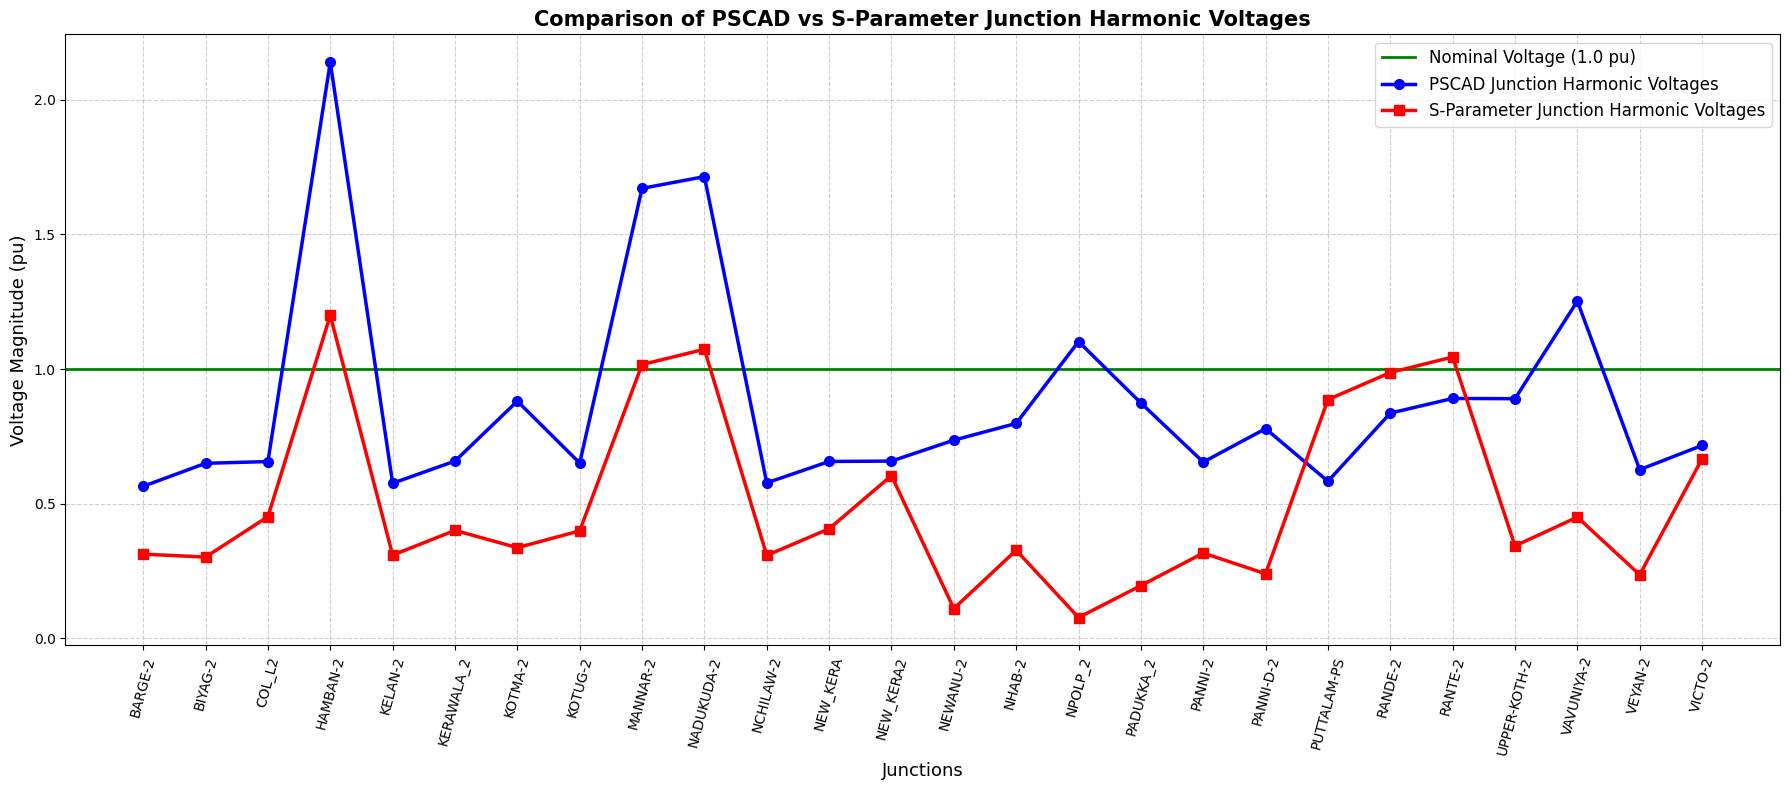

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# Junction names
# ---------------------------------------------------

junctions = [
    "BARGE-2", "BIYAG-2", "COL_L2", "HAMBAN-2", "KELAN-2",
    "KERAWALA_2", "KOTMA-2", "KOTUG-2", "MANNAR-2",
    "NADUKUDA-2", "NCHILAW-2", "NEW_KERA", "NEW_KERA2",
    "NEWANU-2", "NHAB-2", "NPOLP_2", "PADUKKA_2",
    "PANNI-2", "PANNI-D-2", "PUTTALAM-PS", "RANDE-2",
    "RANTE-2", "UPPER-KOTH-2", "VAVUNIYA-2",
    "VEYAN-2", "VICTO-2"
]

# ---------------------------------------------------
# Simulated values
# ---------------------------------------------------

simulate_pu = np.array([
    0.564545, 0.65, 0.656364, 2.140455, 0.575909,
    0.658182, 0.880909, 0.650909, 1.671364,
    1.715, 0.577273, 0.656818, 0.658182,
    0.735909, 0.798182, 1.102273, 0.874091,
    0.654545, 0.778636, 0.583182, 0.836364,
    0.890909, 0.89, 1.252273,
    0.626364, 0.716364
])

# ---------------------------------------------------
# Updated corrected values
# ---------------------------------------------------

corrected_pu = np.array([
    0.3125,  # BARGE-2
    0.3016,  # BIYAG-2
    0.4519,  # COL_L2
    1.1997,  # HAMBAN-2
    0.3089,  # KELAN-2
    0.4007,  # KERAWALA_2
    0.3366,  # KOTMA-2
    0.3989,  # KOTUG-2
    1.0169,  # MANNAR-2
    1.0736,  # NADUKUDA-2
    0.3079,  # NCHILAW-2
    0.4067,  # NEW_KERA
    0.6043,  # NEW_KERA2
    0.1102,  # NEWANU-2
    0.3270,  # NHAB-2
    0.0770,  # NPOLP_2
    0.1956,  # PADUKKA_2
    0.3166,  # PANNI-2
    0.2396,  # PANNI-D-2
    0.8867,  # PUTTALAM-PS
    0.9871,  # RANDE-2
    1.0449,  # RANTE-2
    0.3431,  # UPPER-KOTH-2
    0.4499,  # VAVUNIYA-2
    0.2360,  # VEYAN-2
    0.6663   # VICTO-2
])
# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(18, 8))

# ADDED: Draw a horizontal line at y=1 (Nominal Voltage)
plt.axhline(y=1.0, color='green', linestyle='-', linewidth=2, label='Nominal Voltage (1.0 pu)')

plt.plot(
    junctions,
    simulate_pu,
    marker='o',
    linewidth=2.5,
    markersize=7,
    color='blue',
    label='PSCAD Junction Harmonic Voltages'
)

plt.plot(
    junctions,
    corrected_pu,
    marker='s',
    linewidth=2.5,
    markersize=7,
    color='red',
    label='S-Parameter Junction Harmonic Voltages'
)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------

plt.xticks(rotation=75, fontsize=10)
plt.yticks(fontsize=10)

plt.xlabel('Junctions', fontsize=13)
plt.ylabel('Voltage Magnitude (pu)', fontsize=13)

plt.title(
    'Comparison of PSCAD vs S-Parameter Junction Harmonic Voltages',
    fontsize=15,
    fontweight='bold'
)

plt.grid(True, linestyle='--', alpha=0.6)

# The legend will automatically pick up the new axhline label
plt.legend(fontsize=12)

plt.tight_layout()

# ---------------------------------------------------
# Show plot
# ---------------------------------------------------

plt.show()